# 자동화 예측 모델 성능 평가 및 최적화 — 사용 예제

이 노트북은 `automl_pipeline` 모듈의 주요 기능을 단계별로 실행해볼 수 있도록 구성되어 있습니다.

| 예제 | 내용 |
|------|------|
| 예제 1 | 분류 모델 비교 (유방암 데이터셋) |
| 예제 2 | 회귀 모델 비교 (당뇨병 데이터셋) |
| 예제 3 | 하이퍼파라미터 최적화 단독 실행 |
| 예제 4 | AutoMLPipeline 완전 자동화 |

## 공통 준비 — 라이브러리 임포트

In [1]:
import sys
import copy
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 모듈 경로 등록
sys.path.insert(0, str(Path(".").resolve()))

# 모듈이 이미 로드된 경우 강제 재로드 (커널 재시작 없이 변경 반영)
import importlib
import automl_pipeline
importlib.reload(automl_pipeline)

from automl_pipeline import (
    AutoMLPipeline,
    HyperparameterOptimizer,
    ModelEvaluator,
    PerformanceReporter,
    PARAM_SPACES,
    list_available_models,
    _build_model_catalog,
)

print("임포트 완료")

임포트 완료


---
## 모델 카탈로그 — 사용 가능한 모델 목록

`list_available_models()`로 사용 가능한 모델과 각 모델의 파라미터 후보를 한눈에 확인하세요.  
확인 후 예제별 **'모델 선택'** 셀에서 원하는 모델 이름을 골라 입력하면 됩니다.

In [2]:
# ── 전체 모델 목록 + 파라미터 상세 출력 ──────────────────────
df_catalog = list_available_models(verbose=True)
df_catalog

  사용 가능한 모델 목록  [전체]
                           태스크 설치 여부 파라미터 프리셋  파라미터 수  전체 조합 수 (Grid)
모델명                                                                  
RandomForestClassifier      분류     ✅        ✅       5             288
ExtraTreesClassifier        분류     ✅        ✅       4              96
GradientBoostingClassifier  분류     ✅        ✅       4             108
XGBClassifier               분류     ✅        ✅       7            2187
LGBMClassifier              분류     ✅        ✅       8            6561
LogisticRegression          분류     ✅        ✅       3              30
SVC                         분류     ✅        ✅       3              30
DecisionTreeClassifier      분류     ✅        ✅       4              72
KNeighborsClassifier        분류     ✅        ✅       3              20
AdaBoostClassifier          분류     ✅        ✅       2              12
RandomForestRegressor       회귀     ✅        ✅       4             144
ExtraTreesRegressor         회귀     ✅        ✅       3              48

,태스크,설치 여부,파라미터 프리셋,파라미터 수,전체 조합 수 (Grid)
모델명,,,,,
RandomForestClassifier,분류,✅,✅,5,288
ExtraTreesClassifier,분류,✅,✅,4,96
GradientBoostingClassifier,분류,✅,✅,4,108
XGBClassifier,분류,✅,✅,7,2187
LGBMClassifier,분류,✅,✅,8,6561
LogisticRegression,분류,✅,✅,3,30
SVC,분류,✅,✅,3,30
DecisionTreeClassifier,분류,✅,✅,4,72
KNeighborsClassifier,분류,✅,✅,3,20


태스크별로 필터링해서 볼 수도 있습니다.

```python
list_available_models(task_type='classification')  # 분류 모델만
list_available_models(task_type='regression')      # 회귀 모델만
```

> **파라미터 프리셋 ✅** : `HyperparameterOptimizer`에서 `param_space`를 따로 지정하지 않아도 자동으로 최적화됩니다.

---
## 예제 1: 분류 모델 비교

**데이터셋:** 유방암(Breast Cancer) — sklearn 내장 데이터  
**목표:** 카탈로그에서 선택한 분류 모델들을 교차검증 기반으로 비교합니다.

### 1-1. 데이터 준비

In [3]:
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"클래스: {data.target_names}")

Train: (455, 30), Test: (114, 30)
클래스: ['malignant' 'benign']


### 1-2. 비교할 모델 선택

위 카탈로그에서 **분류 모델** 이름을 골라 리스트에 입력하세요.

In [4]:
MODEL_CATALOG = _build_model_catalog()

# ✏️ 비교할 분류 모델 이름을 리스트에 입력하세요 (2개 이상 권장)
SELECTED_CLASSIFICATION_MODELS = [
    "LogisticRegression",
    "RandomForestClassifier",
    "ExtraTreesClassifier",
    "GradientBoostingClassifier",
    "KNeighborsClassifier",
    "XGBClassifier",
    "LGBMClassifier",
]

for name in SELECTED_CLASSIFICATION_MODELS:
    assert name in MODEL_CATALOG, (
        f"'{name}'은 카탈로그에 없습니다.\n"
        f"선택 가능한 모델: {list(MODEL_CATALOG.keys())}\n"
        f"※ XGBClassifier / LGBMClassifier 는 xgboost / lightgbm 설치 후 사용 가능합니다."
    )

models_cls_cmp = {name: copy.deepcopy(MODEL_CATALOG[name]) for name in SELECTED_CLASSIFICATION_MODELS}

print(f"비교 모델 ({len(models_cls_cmp)}개):")
for name in models_cls_cmp:
    print(f"  - {name}")

비교 모델 (7개):
  - LogisticRegression
  - RandomForestClassifier
  - ExtraTreesClassifier
  - GradientBoostingClassifier
  - KNeighborsClassifier
  - XGBClassifier
  - LGBMClassifier


### 1-3. 모델 비교 실행

In [5]:
evaluator_cls = ModelEvaluator(task_type="classification")
comparison_cls = evaluator_cls.compare_models(models_cls_cmp, X_train, y_train, n_splits=5)

print("[분류 모델 비교 결과]")
display(
    comparison_cls.style
    .background_gradient(axis=0, cmap="RdYlGn")
    .format("{:.4f}")
    .set_caption("분류 모델 비교 결과 (CV 평균, 높을수록 좋음)")
)

[2026-03-25 15:07:56] INFO automl_pipeline - [LogisticRegression] 5-Fold CV 시작...
[2026-03-25 15:07:58] INFO automl_pipeline - [LogisticRegression] 5-Fold CV (classification, 2.62s)
  accuracy                 : 0.9780 ± 0.0098
  f1_weighted              : 0.9780 ± 0.0099
  precision_weighted       : 0.9785 ± 0.0095
  recall_weighted          : 0.9780 ± 0.0098
[2026-03-25 15:07:58] INFO automl_pipeline - [RandomForestClassifier] 5-Fold CV 시작...
[2026-03-25 15:08:00] INFO automl_pipeline - [RandomForestClassifier] 5-Fold CV (classification, 1.98s)
  accuracy                 : 0.9626 ± 0.0179
  f1_weighted              : 0.9627 ± 0.0177
  precision_weighted       : 0.9637 ± 0.0174
  recall_weighted          : 0.9626 ± 0.0179
[2026-03-25 15:08:00] INFO automl_pipeline - [ExtraTreesClassifier] 5-Fold CV 시작...
[2026-03-25 15:08:02] INFO automl_pipeline - [ExtraTreesClassifier] 5-Fold CV (classification, 1.88s)
  accuracy                 : 0.9714 ± 0.0149
  f1_weighted              : 0.9714 ±

[분류 모델 비교 결과]


,accuracy,f1_weighted,precision_weighted,recall_weighted
model,,,,
LogisticRegression,0.9780,0.9780,0.9785,0.9780
RandomForestClassifier,0.9626,0.9627,0.9637,0.9626
ExtraTreesClassifier,0.9714,0.9714,0.9720,0.9714
GradientBoostingClassifier,0.9516,0.9516,0.9523,0.9516
KNeighborsClassifier,0.9604,0.9602,0.9615,0.9604
XGBClassifier,0.9648,0.9648,0.9654,0.9648
LGBMClassifier,0.9648,0.9647,0.9656,0.9648


### 1-4. 비교 결과 시각화 및 리포트 저장

[2026-03-25 15:08:08] INFO automl_pipeline - 모델 비교 그래프 저장: reports\classification\model_comparison_20260325_150808.png


비교 차트 저장 완료: ./reports/classification/


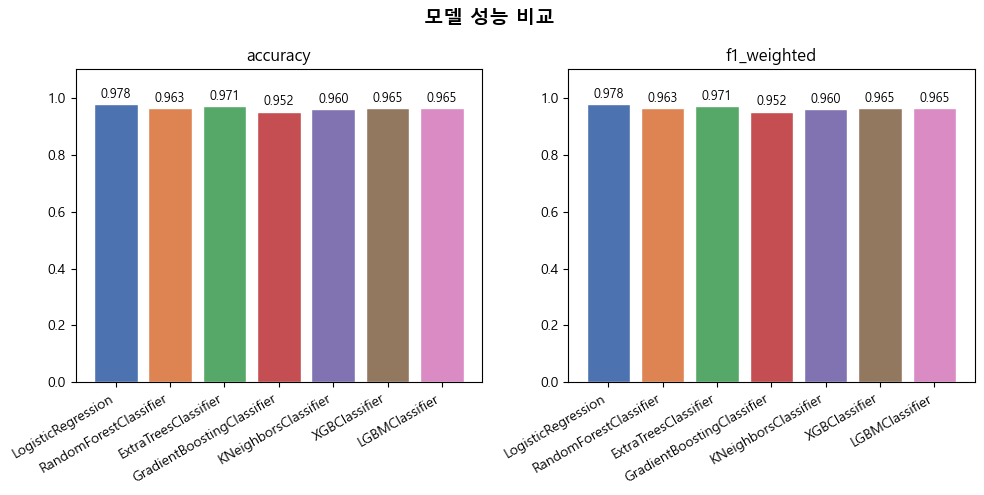

In [6]:
reporter_cls = PerformanceReporter(output_dir="./reports/classification")
reporter_cls.plot_model_comparison(
    comparison_cls,
    metrics=["accuracy", "f1_weighted"],
    save=True,
)
print("비교 차트 저장 완료: ./reports/classification/")

---
## 예제 2: 회귀 모델 비교

**데이터셋:** 당뇨병(Diabetes) — sklearn 내장 데이터  
**목표:** 카탈로그에서 선택한 회귀 모델들을 교차검증 기반으로 비교합니다.

### 2-1. 데이터 준비

In [7]:
data_reg = load_diabetes()
X_r, y_r = data_reg.data, data_reg.target

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42
)

print(f"Train: {X_train_r.shape}, Test: {X_test_r.shape}")

Train: (353, 10), Test: (89, 10)


### 2-2. 비교할 모델 선택

위 카탈로그에서 **회귀 모델** 이름을 골라 리스트에 입력하세요.

In [8]:
MODEL_CATALOG = _build_model_catalog()

# ✏️ 비교할 회귀 모델 이름을 리스트에 입력하세요 (2개 이상 권장)
SELECTED_REGRESSION_MODELS = [
    "Ridge",
    "Lasso",
    "RandomForestRegressor",
    "ExtraTreesRegressor",
    "GradientBoostingRegressor",
    "XGBRegressor",
    "LGBMRegressor",
]

for name in SELECTED_REGRESSION_MODELS:
    assert name in MODEL_CATALOG, (
        f"'{name}'은 카탈로그에 없습니다.\n"
        f"선택 가능한 모델: {list(MODEL_CATALOG.keys())}\n"
        f"※ XGBRegressor / LGBMRegressor 는 xgboost / lightgbm 설치 후 사용 가능합니다."
    )

models_reg = {name: copy.deepcopy(MODEL_CATALOG[name]) for name in SELECTED_REGRESSION_MODELS}

print(f"비교 모델 ({len(models_reg)}개):")
for name in models_reg:
    print(f"  - {name}")

비교 모델 (7개):
  - Ridge
  - Lasso
  - RandomForestRegressor
  - ExtraTreesRegressor
  - GradientBoostingRegressor
  - XGBRegressor
  - LGBMRegressor


### 2-3. 모델 비교 실행

In [9]:
evaluator_reg = ModelEvaluator(task_type="regression")
comparison = evaluator_reg.compare_models(models_reg, X_train_r, y_train_r, n_splits=5)

# 오차 지표(낮을수록 좋음 → 초록)와 R²(높을수록 좋음 → 초록) 구분 강조
err_cols = [c for c in comparison.columns if c != "r2"]
r2_cols  = [c for c in comparison.columns if c == "r2"]

print("[회귀 모델 비교 결과]")
styled = comparison.style.format("{:.4f}")
if err_cols:
    styled = styled.background_gradient(axis=0, cmap="RdYlGn_r", subset=err_cols)
if r2_cols:
    styled = styled.background_gradient(axis=0, cmap="RdYlGn", subset=r2_cols)
display(styled.set_caption("회귀 모델 비교 결과 (CV 평균)"))

[2026-03-25 15:08:08] INFO automl_pipeline - [Ridge] 5-Fold CV 시작...
[2026-03-25 15:08:08] INFO automl_pipeline - [Ridge] 5-Fold CV (regression, 0.01s)
  mean_absolute_error      : 50.7364 ± 4.3783
  root_mean_squared_error  : 60.0214 ± 4.3505
  r2                       : 0.3937 ± 0.0151
[2026-03-25 15:08:08] INFO automl_pipeline - [Lasso] 5-Fold CV 시작...
[2026-03-25 15:08:08] INFO automl_pipeline - [Lasso] 5-Fold CV (regression, 0.01s)
  mean_absolute_error      : 53.6634 ± 4.5025
  root_mean_squared_error  : 62.7435 ± 4.4760
  r2                       : 0.3376 ± 0.0068
[2026-03-25 15:08:08] INFO automl_pipeline - [RandomForestRegressor] 5-Fold CV 시작...
[2026-03-25 15:08:09] INFO automl_pipeline - [RandomForestRegressor] 5-Fold CV (regression, 0.19s)
  mean_absolute_error      : 48.4819 ± 3.0865
  root_mean_squared_error  : 59.4530 ± 2.0363
  r2                       : 0.3990 ± 0.0719
[2026-03-25 15:08:09] INFO automl_pipeline - [ExtraTreesRegressor] 5-Fold CV 시작...
[2026-03-25 15:08:

[회귀 모델 비교 결과]


,mean_absolute_error,root_mean_squared_error,r2
model,,,
Ridge,50.7364,60.0214,0.3937
Lasso,53.6634,62.7435,0.3376
RandomForestRegressor,48.4819,59.4530,0.3990
ExtraTreesRegressor,47.2976,58.0833,0.4290
GradientBoostingRegressor,49.5208,61.1222,0.3670
XGBRegressor,51.1175,64.2249,0.2929
LGBMRegressor,48.1268,59.6095,0.3914


### 2-4. 비교 차트 시각화

[2026-03-25 15:08:11] INFO automl_pipeline - 모델 비교 그래프 저장: reports\regression\model_comparison_20260325_150811.png


리포트 저장 완료: ./reports/regression/


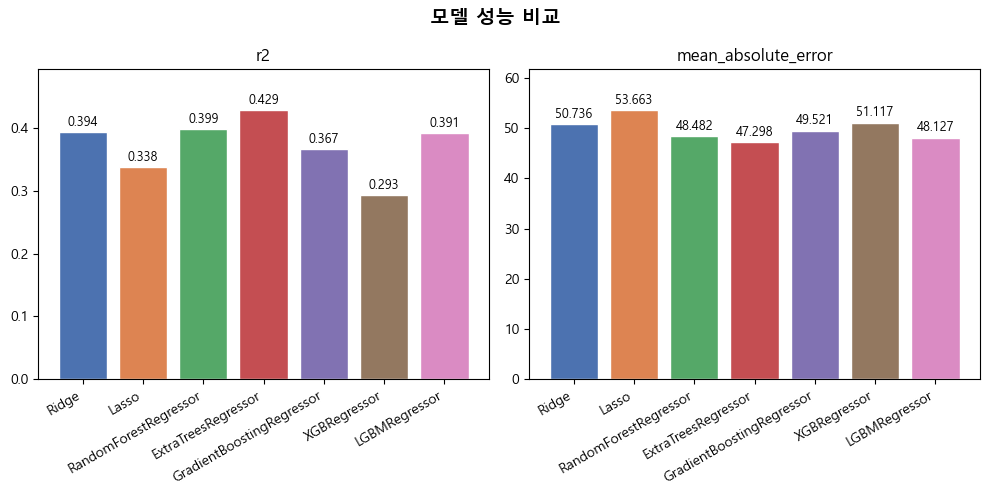

In [10]:
reporter_reg = PerformanceReporter(output_dir="./reports/regression")
reporter_reg.plot_model_comparison(comparison, metrics=["r2", "mean_absolute_error"], save=True)
print("리포트 저장 완료: ./reports/regression/")

---
## 예제 3: 하이퍼파라미터 최적화 단독 실행

**목표:** 카탈로그에서 선택한 모델 하나를 `HyperparameterOptimizer`로 직접 최적화합니다.  
파라미터 프리셋(✅)이 있는 모델은 별도 `param_space` 정의 없이 자동으로 탐색합니다.

### 3-1. 데이터 준비

In [11]:
data_opt = load_breast_cancer()
X_o, y_o = data_opt.data, data_opt.target

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_o, y_o, test_size=0.2, random_state=42, stratify=y_o
)

print(f"Train: {X_train_o.shape}, Test: {X_test_o.shape}")

Train: (455, 30), Test: (114, 30)


### 3-2. 최적화할 모델 선택

파라미터 프리셋(✅)이 있는 모델을 선택하면 `param_space`를 자동으로 불러옵니다.  
직접 `param_space`를 정의하고 싶다면 아래 커스텀 정의 셀을 활용하세요.

In [12]:
MODEL_CATALOG = _build_model_catalog()

# ✏️ 최적화할 모델 이름을 입력하세요
SELECTED_OPT_MODEL = "RandomForestClassifier"

assert SELECTED_OPT_MODEL in MODEL_CATALOG, (
    f"'{SELECTED_OPT_MODEL}'은 카탈로그에 없습니다.\n"
    f"선택 가능한 모델: {list(MODEL_CATALOG.keys())}"
)

model_opt = copy.deepcopy(MODEL_CATALOG[SELECTED_OPT_MODEL])

# 파라미터 프리셋 자동 로드
if SELECTED_OPT_MODEL in PARAM_SPACES:
    param_space = PARAM_SPACES[SELECTED_OPT_MODEL]
    print(f"'{SELECTED_OPT_MODEL}' 파라미터 프리셋을 자동으로 불러왔습니다.")
else:
    param_space = None
    print(f"⚠️ '{SELECTED_OPT_MODEL}'은 파라미터 프리셋이 없습니다. 아래 셀에서 직접 정의하세요.")

print(f"\n선택 모델: {SELECTED_OPT_MODEL}")
if param_space:
    for k, v in param_space.items():
        print(f"  {k}: {v}")

'RandomForestClassifier' 파라미터 프리셋을 자동으로 불러왔습니다.

선택 모델: RandomForestClassifier
  n_estimators: [100, 200, 300, 500]
  max_depth: [None, 5, 10, 20]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  max_features: ['sqrt', 'log2']


### 3-3. (선택) 파라미터 공간 직접 정의

파라미터 프리셋을 그대로 사용하거나, 아래에서 직접 수정해 사용할 수 있습니다.  
프리셋을 그대로 사용하려면 **이 셀을 건너뛰세요**.

In [13]:
# ✏️ 파라미터 공간을 직접 정의하려면 주석을 해제하고 수정하세요
# param_space = {
#     "n_estimators":      [50, 100, 200, 300],
#     "max_depth":         [None, 5, 10, 15],
#     "min_samples_split": [2, 5, 10],
#     "max_features":      ["sqrt", "log2"],
# }

print("현재 사용할 파라미터 공간:")
if param_space:
    for k, v in param_space.items():
        print(f"  {k}: {v}")
else:
    print("  ⚠️ 파라미터 공간이 정의되지 않았습니다. 위 셀에서 직접 정의해주세요.")

현재 사용할 파라미터 공간:
  n_estimators: [100, 200, 300, 500]
  max_depth: [None, 5, 10, 20]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  max_features: ['sqrt', 'log2']


### 3-4. 최적화 실행

In [14]:
assert param_space is not None, "파라미터 공간이 정의되지 않았습니다. 위 셀을 확인하세요."

optimizer = HyperparameterOptimizer(
    strategy="random",
    scoring="f1_weighted",
    cv=5,
    n_iter=20,
    random_state=42,
)

opt_result = optimizer.optimize(
    model_opt, X_train_o, y_train_o, param_space, model_name=SELECTED_OPT_MODEL
)

[2026-03-25 15:08:12] INFO automl_pipeline - [RandomForestClassifier] RANDOM 탐색 시작 (scoring=f1_weighted)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


[2026-03-25 15:08:16] INFO automl_pipeline - [RandomForestClassifier] random 최적화 완료 (4.34s)
  최고 점수 (f1_weighted): 0.9604
  최적 파라미터:
    n_estimators: 500
    min_samples_split: 2
    min_samples_leaf: 2
    max_features: log2
    max_depth: 10


### 3-5. 최적화 결과 확인

In [15]:
print("최적 파라미터:")
for k, v in opt_result.best_params.items():
    print(f"  {k}: {v}")
print(f"\n최고 CV 점수 (f1_weighted): {opt_result.best_score:.4f}")

최적 파라미터:
  n_estimators: 500
  min_samples_split: 2
  min_samples_leaf: 2
  max_features: log2
  max_depth: 10

최고 CV 점수 (f1_weighted): 0.9604


### 3-6. 최적 모델로 최종 평가

In [16]:
best_model = opt_result.best_model
y_pred_opt = best_model.predict(X_test_o)
y_prob_opt = best_model.predict_proba(X_test_o) if hasattr(best_model, "predict_proba") else None

evaluator_opt = ModelEvaluator(task_type="classification")
final_result = evaluator_opt.evaluate(
    y_test_o, y_pred_opt, y_prob=y_prob_opt,
    model_name=f"{SELECTED_OPT_MODEL}_Optimized",
)
print(final_result.summary())

[2026-03-25 15:08:16] INFO automl_pipeline - [RandomForestClassifier_Optimized] classification 평가 (0.01s)
  accuracy            : 0.9561
  precision           : 0.9561
  recall              : 0.9561
  f1                  : 0.9560
  roc_auc             : 0.9931


[RandomForestClassifier_Optimized] classification 평가 (0.01s)
  accuracy            : 0.9561
  precision           : 0.9561
  recall              : 0.9561
  f1                  : 0.9560
  roc_auc             : 0.9931


---
## 예제 4: AutoMLPipeline — 완전 자동화

**목표:** 선택한 분류 모델들을 자동으로 비교 → 하이퍼파라미터 최적화 → 최종 평가 → 리포트 저장합니다.  
> `opt_iter=20`은 빠른 데모용입니다. 실제 사용 시 50~100을 권장합니다.

### 4-1. 데이터 준비

In [17]:
data_cls = load_breast_cancer()
X_c, y_c = data_cls.data, data_cls.target

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c
)

print(f"Train: {X_train_c.shape}, Test: {X_test_c.shape}")

Train: (455, 30), Test: (114, 30)


### 4-2. 파이프라인에 사용할 모델 선택

위 카탈로그에서 **분류 모델** 이름을 골라 리스트에 입력하세요.  
> 파라미터 프리셋(✅)이 있는 모델은 `param_space`를 별도로 정의하지 않아도 자동으로 최적화됩니다.

In [18]:
MODEL_CATALOG = _build_model_catalog()

# ✏️ AutoMLPipeline에 사용할 분류 모델 이름을 리스트에 입력하세요
SELECTED_PIPELINE_MODELS = [
    "LogisticRegression",
    "RandomForestClassifier",
    "ExtraTreesClassifier",
    "GradientBoostingClassifier",
    "KNeighborsClassifier",
    "XGBClassifier",
    "LGBMClassifier",
]

for name in SELECTED_PIPELINE_MODELS:
    assert name in MODEL_CATALOG, (
        f"'{name}'은 카탈로그에 없습니다.\n"
        f"선택 가능한 모델: {list(MODEL_CATALOG.keys())}\n"
        f"※ XGBClassifier / LGBMClassifier 는 xgboost / lightgbm 설치 후 사용 가능합니다."
    )

models_cls = {name: copy.deepcopy(MODEL_CATALOG[name]) for name in SELECTED_PIPELINE_MODELS}

print(f"파이프라인 모델 ({len(models_cls)}개):")
for name in models_cls:
    has_space = "✅ 파라미터 프리셋 있음" if name in PARAM_SPACES else "⚠️ 파라미터 프리셋 없음 (최적화 스킵)"
    print(f"  - {name}: {has_space}")

파이프라인 모델 (7개):
  - LogisticRegression: ✅ 파라미터 프리셋 있음
  - RandomForestClassifier: ✅ 파라미터 프리셋 있음
  - ExtraTreesClassifier: ✅ 파라미터 프리셋 있음
  - GradientBoostingClassifier: ✅ 파라미터 프리셋 있음
  - KNeighborsClassifier: ✅ 파라미터 프리셋 있음
  - XGBClassifier: ✅ 파라미터 프리셋 있음
  - LGBMClassifier: ✅ 파라미터 프리셋 있음


### 4-3. 파이프라인 실행

[2026-03-25 15:08:16] INFO automl_pipeline - 태스크 유형: classification | 평가 지표: f1_weighted
[2026-03-25 15:08:16] INFO automl_pipeline - ==================================================
[2026-03-25 15:08:16] INFO automl_pipeline - STEP 1: 다중 모델 교차검증 비교
[2026-03-25 15:08:16] INFO automl_pipeline - ==================================================
[2026-03-25 15:08:16] INFO automl_pipeline - [LogisticRegression] 5-Fold CV 시작...
[2026-03-25 15:08:16] INFO automl_pipeline - [LogisticRegression] 5-Fold CV (classification, 0.10s)
  accuracy                 : 0.9451 ± 0.0155
  f1_weighted              : 0.9448 ± 0.0155
  precision_weighted       : 0.9456 ± 0.0161
  recall_weighted          : 0.9451 ± 0.0155
[2026-03-25 15:08:16] INFO automl_pipeline - [RandomForestClassifier] 5-Fold CV 시작...
[2026-03-25 15:08:16] INFO automl_pipeline - [RandomForestClassifier] 5-Fold CV (classification, 0.16s)
  accuracy                 : 0.9626 ± 0.0179
  f1_weighted              : 0.9627 ± 0.0177
  precisio

Fitting 5 folds for each of 20 candidates, totalling 100 fits


[2026-03-25 15:08:22] INFO automl_pipeline - [ExtraTreesClassifier] random 최적화 완료 (2.60s)
  최고 점수 (f1_weighted): 0.9714
  최적 파라미터:
    n_estimators: 100
    min_samples_split: 2
    max_features: sqrt
    max_depth: None
[2026-03-25 15:08:22] INFO automl_pipeline - 최적화 결과 저장: reports\automl\ExtraTreesClassifier_optimization_20260325_150816_summary.json
[2026-03-25 15:08:22] INFO automl_pipeline - ==================================================
[2026-03-25 15:08:22] INFO automl_pipeline - STEP 3: 최종 테스트 셋 평가
[2026-03-25 15:08:22] INFO automl_pipeline - ==================================================
[2026-03-25 15:08:22] INFO automl_pipeline - [ExtraTreesClassifier_optimized] classification 평가 (0.01s)
  accuracy            : 0.9561
  precision           : 0.9561
  recall              : 0.9561
  f1                  : 0.9560
  roc_auc             : 0.9927
[2026-03-25 15:08:22] INFO automl_pipeline - 평가 결과 저장: reports\automl\ExtraTreesClassifier_evaluation_20260325_150816.json
[2026-

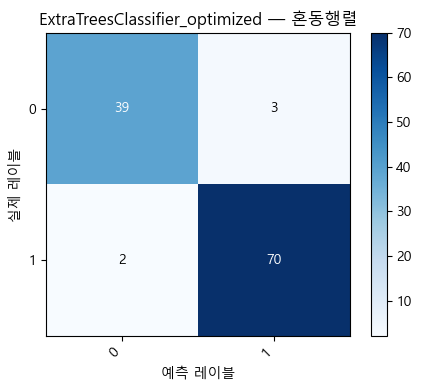

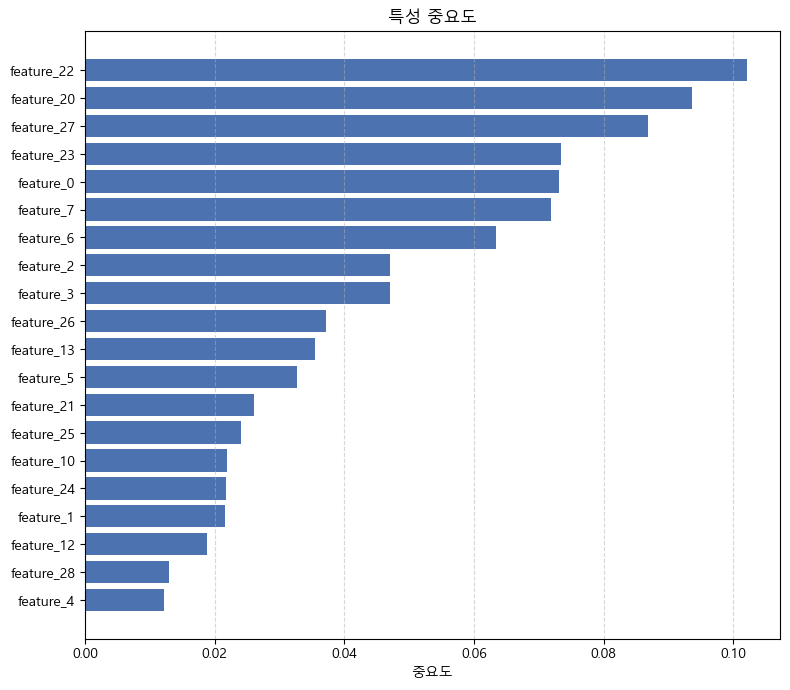

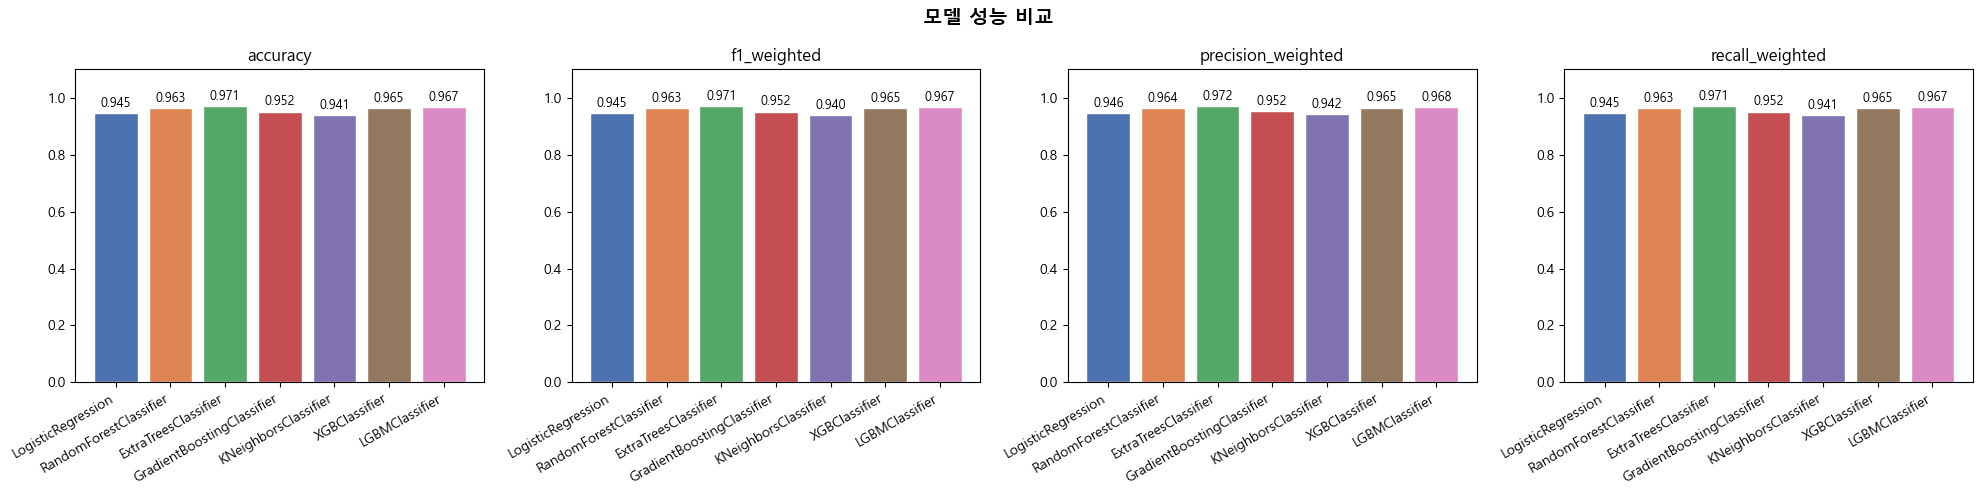

In [19]:
pipeline = AutoMLPipeline(
    task_type="classification",
    cv_folds=5,
    opt_strategy="random",
    opt_iter=20,           # 빠른 데모용; 실제 사용 시 50~100 권장
    output_dir="./reports/automl",
    random_state=42,
)

result_pipeline = pipeline.run(
    models=models_cls,
    X_train=X_train_c, y_train=y_train_c,
    X_test=X_test_c,   y_test=y_test_c,
    optimize=True,
)

### 4-4. 결과 확인

In [20]:
print(result_pipeline.summary())
print("\n리포트 저장 완료: ./reports/automl/")

  AutoML 파이프라인 완료
  태스크 유형    : classification
  최적 모델      : ExtraTreesClassifier
  총 소요 시간   : 6.25s
  결과 저장 경로 : reports\automl
  최종 테스트 메트릭:
    accuracy            : 0.9561
    precision           : 0.9561
    recall              : 0.9561
    f1                  : 0.9560
    roc_auc             : 0.9927

리포트 저장 완료: ./reports/automl/
